In [125]:
# Importar librerias y DF
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn import linear_model
regr = linear_model.LinearRegression()
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

In [126]:
df = pd.read_excel("Mexico GDP.xlsx")
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


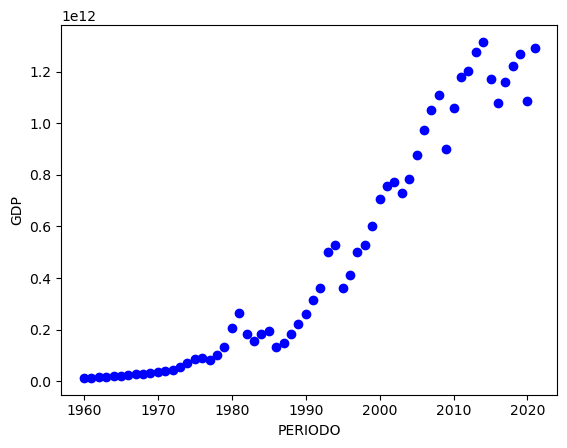

In [127]:
#Visualizar grafica
plt.scatter(df.Periodo, df.GDP, color= 'blue')
plt.xlabel('PERIODO')
plt.ylabel('GDP')
plt.show()

### procedemos a modelo logistico

In [128]:
x = df['Periodo'].values
y = df['GDP'].values

In [129]:
# Modelo solicitado 
def modelo (x,Beta_0, Beta_1):
    return 1 / (1 + np.exp(Beta_0 * (x - Beta_1)))

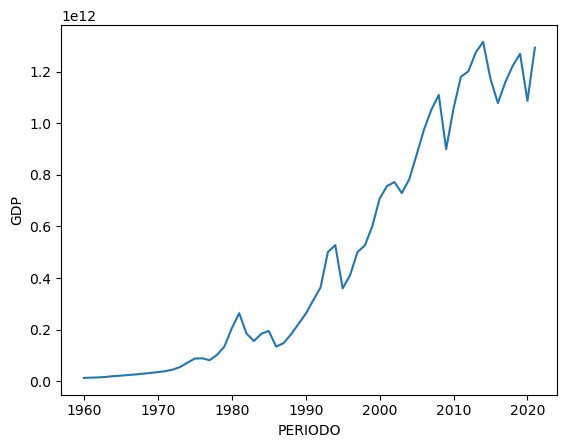

beta_0 =  1.0 beta_1 =  1.0


C:\Users\Darki\AppData\Local\Temp\ipykernel_16636\3371396057.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(Beta_0 * (x - Beta_1)))
C:\Users\Darki\AppData\Local\Temp\ipykernel_16636\3467783908.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(modelo, x, y)


In [130]:
#Parece que al intentar imprimir Beta0 y Beta1 se esta generando un warning de overflow, 
#lo mas seguro es que sea por los numeros tan grandes que tiene el PIB  
plt.plot (x, y)
plt.xlabel('PERIODO')
plt.ylabel('GDP')
plt.show()

popt, pcov = curve_fit(modelo, x, y)
print('beta_0 = ', popt[0], 'beta_1 = ', popt[1])

In [131]:
#Normalizamos las variables dividiendolas entre el max de cada columna, esto hace que los numeros se hagan mas pequeños 
x_norm = x / x.max()
y_norm = y / y.max()

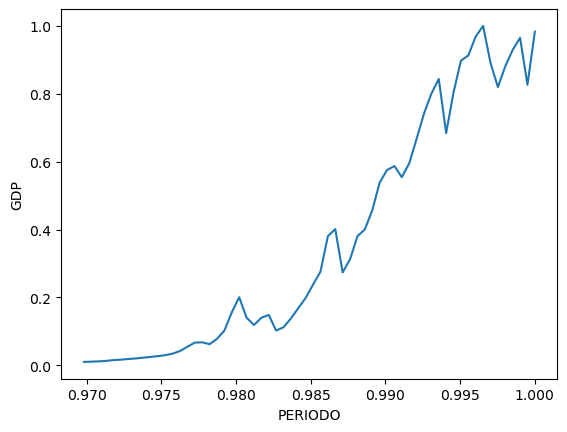

beta_0 =  -271.5977402730898 beta_1 =  0.989293900432664


In [132]:
#El error fue corregido y ahora ya se muestan los valores Beta

plt.plot (x_norm, y_norm)
plt.xlabel('PERIODO')
plt.ylabel('GDP')
plt.show()

popt, pcov = curve_fit(modelo, x_norm, y_norm)
print('beta_0 = ', popt[0], 'beta_1 = ', popt[1])

# Implementacion modelo predictivo 

In [133]:
#Creacion de mascara:
msk = np.random.rand(len(x_norm))<= 0.8
msk

array([ True,  True,  True,  True,  True,  True, False,  True, False,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True, False,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True,  True, False,  True,  True, False,  True,  True])

In [134]:
train_x = x_norm[msk]
test_x= x_norm[~msk]
train_y = y_norm[msk]
test_y = y_norm[~msk]

In [135]:
popt, pocv = curve_fit(modelo, train_x, train_y)
print('beta_0 = ', popt[0], 'beta_1 = ', popt[1])

beta_0 =  -267.28244112304816 beta_1 =  0.9892007283241989


In [141]:
#Pronostico
y_hat = modelo(test_x, *popt)

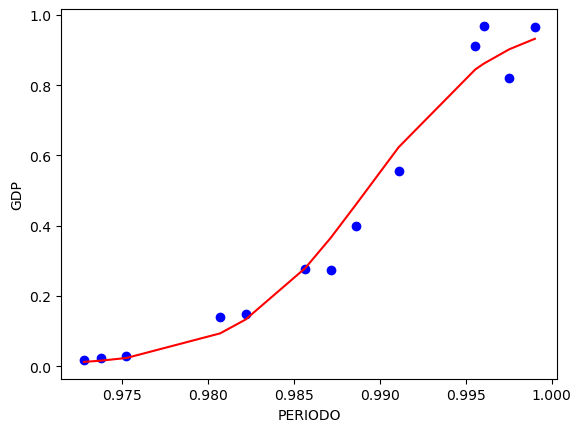

In [137]:
plt.plot (test_x, test_y, 'bo')
plt.plot(test_x,y_hat ,'-r')
plt.ylabel('GDP')
plt.xlabel('PERIODO')
plt.show()

In [142]:
#Los coheficientes muestran buen nivel de prediccion.
print ("Mean absolute error : %.4f" % np.mean(np.absolute(y_hat - test_y)))
print ("Residual sum of squares  (MSE): %.4f" % np.mean((y_hat - test_y) ** 2))
print ("R2-score: %.4f" % r2_score(test_y, y_hat))

Mean absolute error : 0.0459
Residual sum of squares  (MSE): 0.0033
R2-score: 0.9742


In [139]:
#Normalizar año 2022, para hacer prediccion:

x_norm2022 = 2022 / x.max()

#Incertamos 2022 normalizado en el modelo 
y_2022_norm = modelo(x_norm2022, *popt)

#Desnormalizamos
PIB2022 = y_2022_norm * y.max()
PIB2022

1254071844024.14